# 👁️ Eye Disease Classification Model — Training Pipeline

**Objective:** Build a high-performance deep learning model that classifies **4 eye conditions** (Blepharitis, Conjunctivitis, Normal, Uveitis) using **transfer learning** with a pre-trained ResNet-18 backbone, optimized for **TFLite mobile deployment**.

---

### Notebook Structure
1. **Environment Setup** — Imports, device configuration, reproducibility
2. **Configuration** — Hyperparameters, paths, constants
3. **Exploratory Data Analysis** — Class distribution, sample visualization
4. **Data Pipeline** — Transforms, train/val/test split, dataloaders
5. **Model Architecture** — ResNet-18 transfer learning with custom head
6. **Training Configuration** — Loss function (weighted), optimizer, scheduler
7. **Training Loop** — GPU-accelerated training with validation monitoring
8. **Training History** — Loss & accuracy curves
9. **Model Evaluation** — Classification report, confusion matrix
10. **Inference Demo** — Predictions on sample images
11. **Model Export** — TFLite conversion for Flutter deployment

---
> **Target:** Mobile Flutter Application (TFLite)  
> **Framework:** PyTorch + CUDA  
> **Architecture:** ResNet-18 (ImageNet pretrained)

## 1. Environment Setup
Import all required libraries and configure the training device.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torch.cuda.amp import GradScaler, autocast
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device Configuration ─────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device       : {device}")
if device.type == 'cuda':
    print(f"🎮  GPU          : {torch.cuda.get_device_name(0)}")
    print(f"💾  GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"🔥  PyTorch      : {torch.__version__}")
print(f"🌱  Random Seed  : {SEED}")

🖥️  Device       : cuda
🎮  GPU          : NVIDIA GeForce RTX 4050 Laptop GPU
💾  GPU Memory   : 6.4 GB
🔥  PyTorch      : 2.6.0+cu124
🌱  Random Seed  : 42


## 2. Configuration
Define all hyperparameters and paths in one centralized block for easy experimentation.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path(r"c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes")
DATA_DIR   = BASE_DIR / "Dataset"
MODEL_DIR  = BASE_DIR / "models"
SPLIT_DIR  = BASE_DIR / "data_split"  # Will hold train/val/test splits
MODEL_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
NUM_CLASSES   = len([d for d in DATA_DIR.iterdir() if d.is_dir()])
BATCH_SIZE    = 32
NUM_EPOCHS    = 25
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-4
IMG_SIZE      = 224
NUM_WORKERS   = 2
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15

# ── Class Names ──────────────────────────────────────────────────────────────
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

print("✅ Configuration loaded successfully!")
print(f"   Dataset Dir   : {DATA_DIR}")
print(f"   Batch Size    : {BATCH_SIZE}")
print(f"   Epochs        : {NUM_EPOCHS}")
print(f"   Learning Rate : {LEARNING_RATE}")
print(f"   Image Size    : {IMG_SIZE}x{IMG_SIZE}")
print(f"   Num Classes   : {NUM_CLASSES}")
print(f"   Classes       : {CLASS_NAMES}")
print(f"   Val Split     : {VAL_SPLIT*100:.0f}%")
print(f"   Test Split    : {TEST_SPLIT*100:.0f}%")

✅ Configuration loaded successfully!
   Dataset Dir   : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\Dataset
   Batch Size    : 32
   Epochs        : 25
   Learning Rate : 0.0001
   Image Size    : 224x224
   Num Classes   : 4
   Classes       : ['Blepharitis', 'Conjunctivitis', 'Normal', 'Uveitis']
   Val Split     : 15%
   Test Split    : 15%


## 3. Exploratory Data Analysis (EDA)
Understanding the dataset distribution is critical before training. Let's analyze class frequencies and visualize sample images.

In [3]:
# ── Count images per class ───────────────────────────────────────────────────
def count_images(directory):
    """Count images in each class folder."""
    counts = {}
    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            n = len([f for f in class_folder.iterdir() if f.is_file()])
            counts[class_folder.name] = n
    return counts

total_counts = count_images(DATA_DIR)

# Create a summary DataFrame
df = pd.DataFrame({
    "Class": list(total_counts.keys()),
    "Images": list(total_counts.values()),
})
df = df.sort_values("Images", ascending=False).reset_index(drop=True)

print(f"📊 Dataset Summary")
print(f"   Total Classes  : {len(df)}")
print(f"   Total Images   : {df['Images'].sum():,}")
print()
df

📊 Dataset Summary
   Total Classes  : 4
   Total Images   : 1,113



,Class,Images
0,Conjunctivitis,357
1,Normal,311
2,Uveitis,223
3,Blepharitis,222


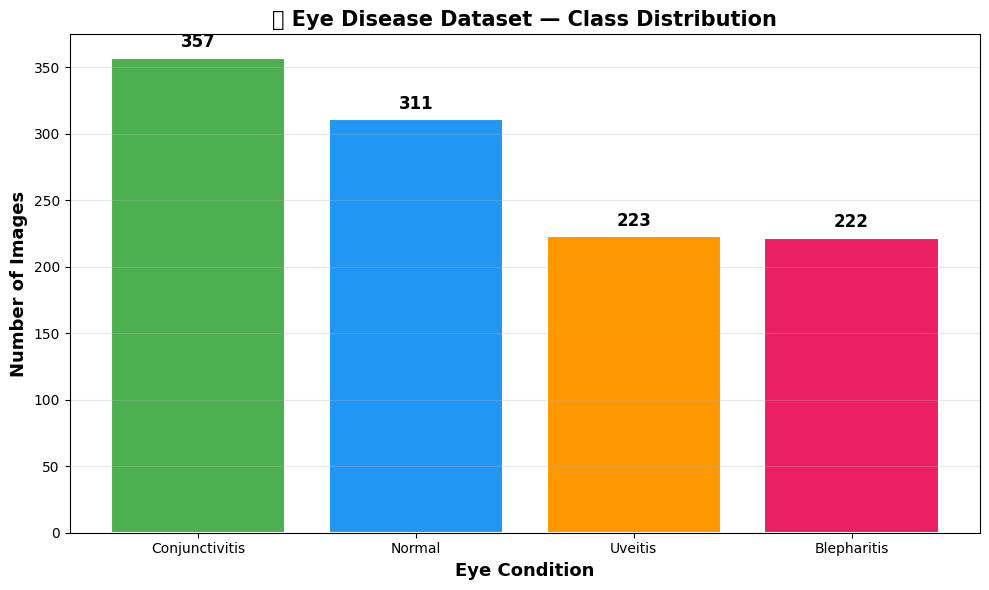

⚠️  Class Imbalance Ratio: 1.6x
   Largest class  : Conjunctivitis (357 images)
   Smallest class : Blepharitis (222 images)


In [4]:
# ── Class Distribution Bar Chart ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]
bars = ax.bar(df["Class"], df["Images"], color=colors[:len(df)], edgecolor="white", linewidth=1.5)

for bar, count in zip(bars, df["Images"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xlabel("Eye Condition", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Images", fontsize=13, fontweight="bold")
ax.set_title("📊 Eye Disease Dataset — Class Distribution", fontsize=15, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ── Highlight class imbalance ────────────────────────────────────────────────
max_class = df.loc[df["Images"].idxmax()]
min_class = df.loc[df["Images"].idxmin()]
ratio = max_class["Images"] / min_class["Images"]
print(f"⚠️  Class Imbalance Ratio: {ratio:.1f}x")
print(f"   Largest class  : {max_class['Class']} ({max_class['Images']} images)")
print(f"   Smallest class : {min_class['Class']} ({min_class['Images']} images)")

### Sample Images
Let's visualize random samples from each eye condition to understand the visual patterns.

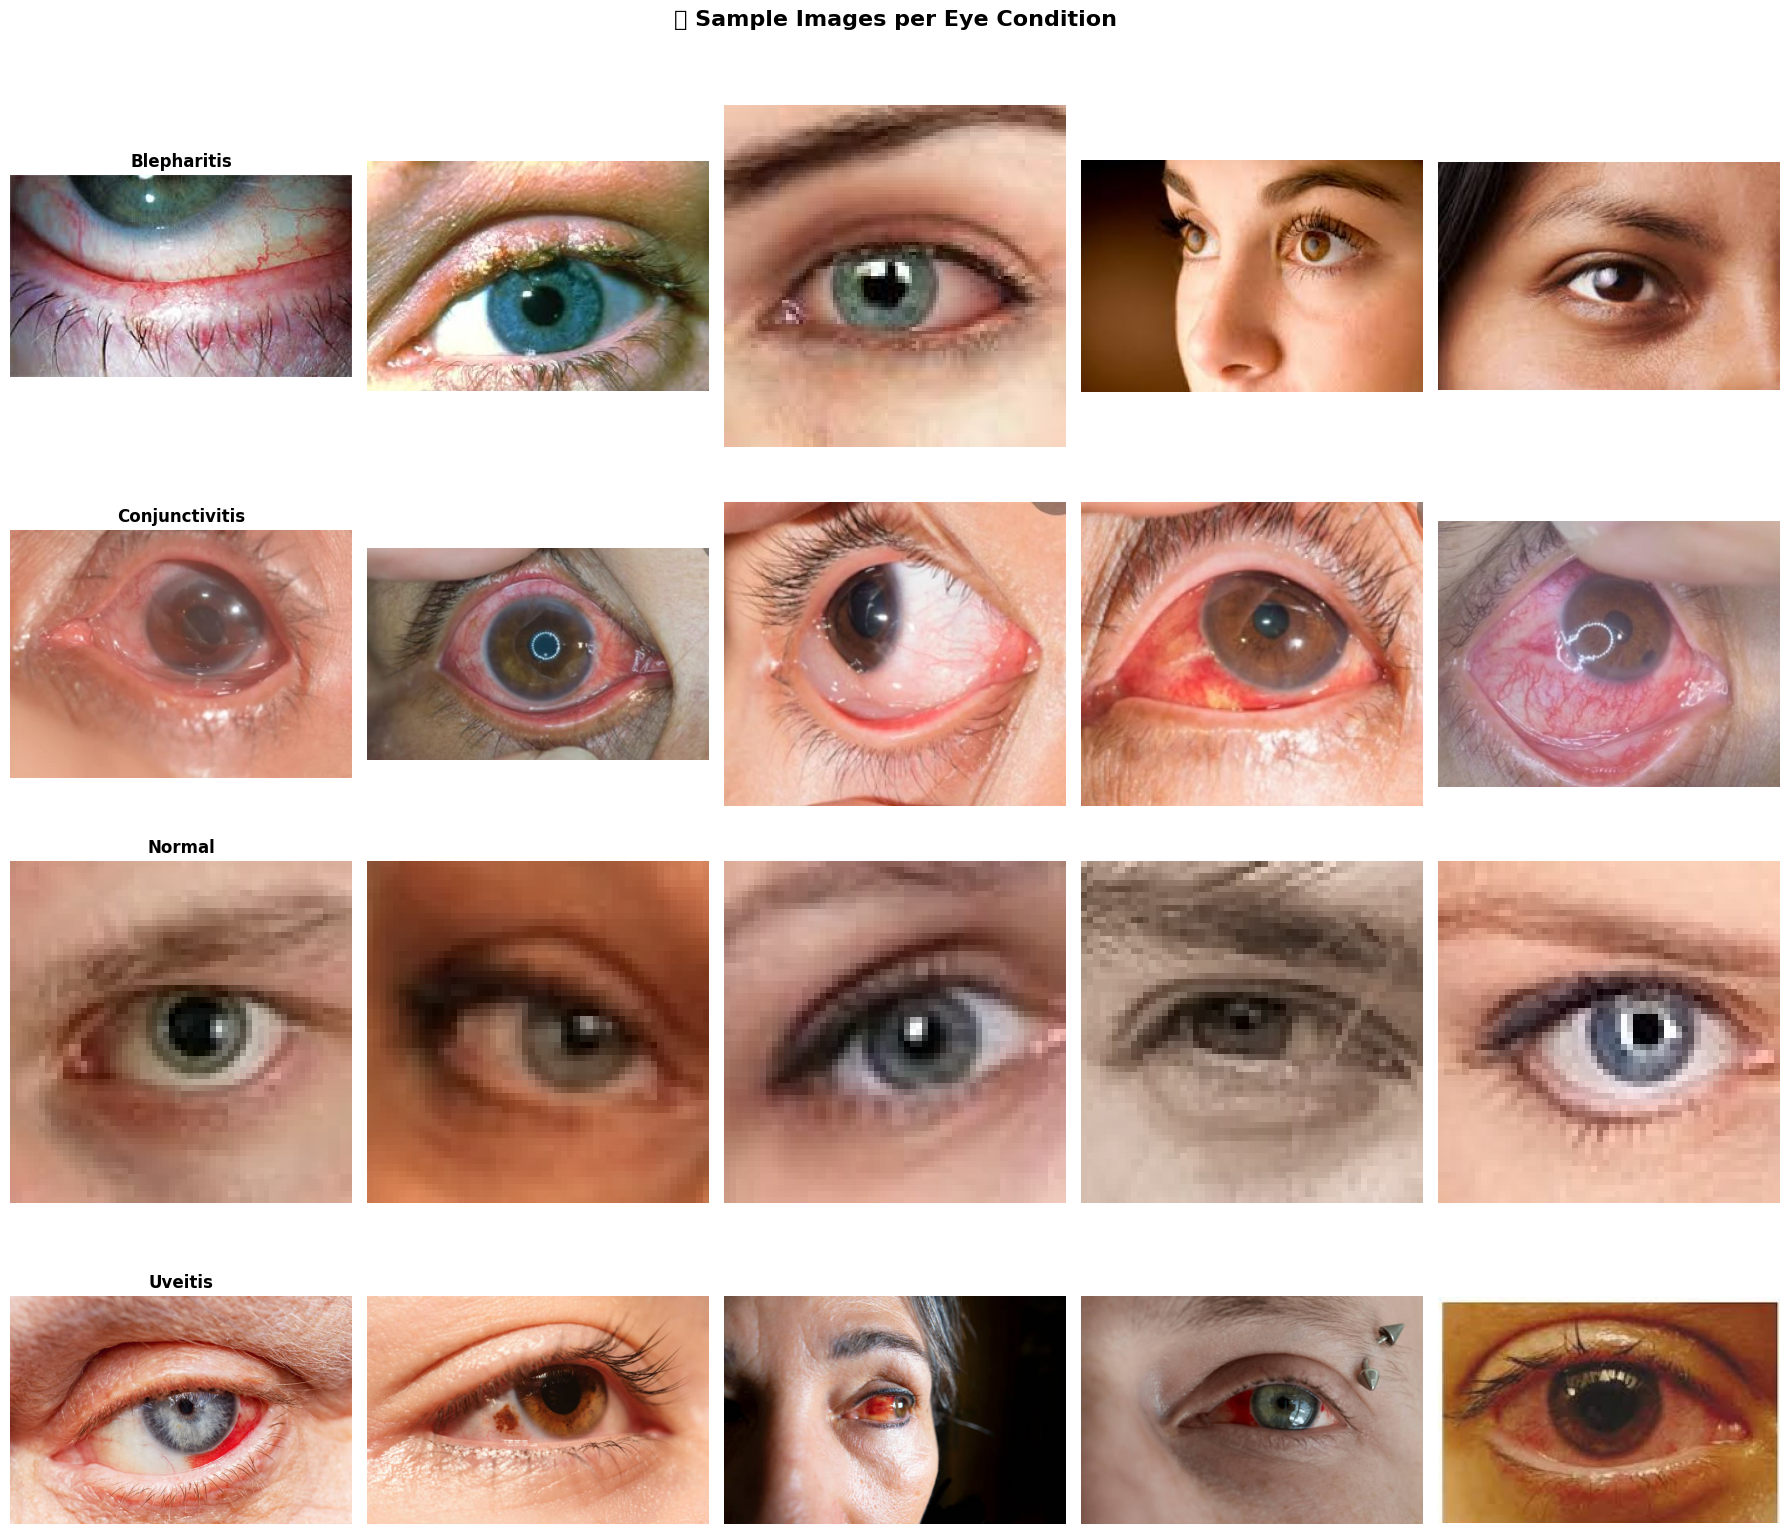

In [5]:
# ── Visualize Sample Images ──────────────────────────────────────────────────
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(18, 4 * NUM_CLASSES))
fig.suptitle("👁️ Sample Images per Eye Condition", fontsize=16, fontweight="bold", y=1.01)

for i, class_name in enumerate(CLASS_NAMES):
    class_path = DATA_DIR / class_name
    imgs = list(class_path.glob("*"))
    selected = random.sample(imgs, min(5, len(imgs)))
    for j, img_path in enumerate(selected):
        try:
            img = Image.open(img_path).convert("RGB")
            axes[i][j].imshow(img)
            axes[i][j].axis("off")
            if j == 0:
                axes[i][j].set_title(class_name, fontsize=12, fontweight="bold")
        except Exception:
            axes[i][j].axis("off")

plt.tight_layout()
plt.show()

## 4. Data Pipeline
Set up augmentation transforms, split dataset into train/val/test, and create DataLoaders.

Since the raw dataset is a single folder without pre-defined splits, we perform a **stratified split** to maintain class proportions across train (70%), validation (15%), and test (15%) sets.

In [6]:
# ── Data Augmentation & Normalization ─────────────────────────────────────────
# ImageNet mean & std for pretrained ResNet-18
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("✅ Transforms defined")
print(f"   Train augmentations: RandomCrop, HFlip, VFlip, Rotation, ColorJitter, Affine")
print(f"   Val/Test: Resize + Normalize only")

✅ Transforms defined
   Train augmentations: RandomCrop, HFlip, VFlip, Rotation, ColorJitter, Affine
   Val/Test: Resize + Normalize only


In [7]:
# ── Create Stratified Train/Val/Test Split ────────────────────────────────────
# Load full dataset with basic transform first for splitting
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)
all_targets = [s[1] for s in full_dataset.samples]
all_indices = list(range(len(full_dataset)))

# First split: separate test set
train_val_idx, test_idx = train_test_split(
    all_indices, test_size=TEST_SPLIT, stratify=all_targets, random_state=SEED
)

# Second split: separate validation from training
train_val_targets = [all_targets[i] for i in train_val_idx]
relative_val_size = VAL_SPLIT / (1 - TEST_SPLIT)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=relative_val_size, stratify=train_val_targets, random_state=SEED
)

print(f"📂 Dataset Split:")
print(f"   Train : {len(train_idx)} images ({len(train_idx)/len(full_dataset)*100:.1f}%)")
print(f"   Val   : {len(val_idx)} images ({len(val_idx)/len(full_dataset)*100:.1f}%)")
print(f"   Test  : {len(test_idx)} images ({len(test_idx)/len(full_dataset)*100:.1f}%)")
print(f"   Total : {len(full_dataset)} images")

📂 Dataset Split:
   Train : 779 images (70.0%)
   Val   : 167 images (15.0%)
   Test  : 167 images (15.0%)
   Total : 1113 images


In [8]:
# ── Create Dataset Subsets with Proper Transforms ─────────────────────────────
train_dataset_aug = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_dataset       = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)
test_dataset      = datasets.ImageFolder(root=DATA_DIR, transform=val_test_transform)

train_subset = Subset(train_dataset_aug, train_idx)
val_subset   = Subset(val_dataset, val_idx)
test_subset  = Subset(test_dataset, test_idx)

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("✅ DataLoaders created")
print(f"   Train batches : {len(train_loader)}")
print(f"   Val batches   : {len(val_loader)}")
print(f"   Test batches  : {len(test_loader)}")

✅ DataLoaders created
   Train batches : 25
   Val batches   : 6
   Test batches  : 6


## 5. Model Architecture
We use **ResNet-18** pretrained on ImageNet as a feature extractor, replacing the final fully connected layer with a custom classification head for our 4 eye disease classes.

The architecture is optimized for mobile deployment (TFLite).

In [9]:
# ── Build Model ──────────────────────────────────────────────────────────────
def build_model(num_classes, pretrained=True):
    """Build a ResNet-18 model with a custom classification head."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
    
    # Freeze early layers for transfer learning stability
    for param in list(model.parameters())[:-20]:
        param.requires_grad = False
    
    # Replace the final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, num_classes)
    )
    
    return model

model = build_model(NUM_CLASSES).to(device)

# ── Model Summary ────────────────────────────────────────────────────────────
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"🏗️  Model Architecture: ResNet-18 (Transfer Learning)")
print(f"   Total Parameters     : {total_params:,}")
print(f"   Trainable Parameters : {trainable_params:,}")
print(f"   Frozen Parameters    : {frozen_params:,}")
print(f"   Output Classes       : {NUM_CLASSES}")
print(f"   Class Names          : {CLASS_NAMES}")

🏗️  Model Architecture: ResNet-18 (Transfer Learning)
   Total Parameters     : 11,308,868
   Trainable Parameters : 9,116,420
   Frozen Parameters    : 2,192,448
   Output Classes       : 4
   Class Names          : ['Blepharitis', 'Conjunctivitis', 'Normal', 'Uveitis']


## 6. Training Configuration
Set up weighted cross-entropy loss (to handle class imbalance), optimizer, and learning rate scheduler.

In [10]:
# ── Compute Class Weights for Imbalanced Data ─────────────────────────────────
train_targets = [all_targets[i] for i in train_idx]
class_counts = Counter(train_targets)
total_train = len(train_targets)

# Inverse frequency weighting
class_weights = []
for i in range(NUM_CLASSES):
    w = total_train / (NUM_CLASSES * class_counts[i])
    class_weights.append(w)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("⚖️  Class Weights (inverse frequency):")
for i, name in enumerate(CLASS_NAMES):
    print(f"   {name:20s} : {class_weights[i]:.4f} ({class_counts[i]} train samples)")

# ── Loss, Optimizer, Scheduler ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = GradScaler()  # Mixed precision training

print(f"\n🔧 Training Config:")
print(f"   Loss      : Weighted CrossEntropyLoss")
print(f"   Optimizer : AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"   Scheduler : CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"   AMP       : Enabled (Mixed Precision)")

⚖️  Class Weights (inverse frequency):
   Blepharitis          : 1.2484 (156 train samples)
   Conjunctivitis       : 0.7790 (250 train samples)
   Normal               : 0.8975 (217 train samples)
   Uveitis              : 1.2484 (156 train samples)

🔧 Training Config:
   Loss      : Weighted CrossEntropyLoss
   Optimizer : AdamW (lr=0.0001, wd=0.0001)
   Scheduler : CosineAnnealingLR (T_max=25)
   AMP       : Enabled (Mixed Precision)


## 7. Training Loop
GPU-accelerated training with mixed precision (AMP), validation monitoring, and best model checkpointing.

In [11]:
# ── Training & Validation Functions ───────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    """Train the model for one epoch with mixed precision."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    """Evaluate model on validation/test set."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("✅ Training functions defined")

✅ Training functions defined


In [12]:
# ── Training Execution ───────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
best_val_acc = 0.0
best_model_path = MODEL_DIR / "eye_disease_resnet18_best.pth"
patience = 7
patience_counter = 0

print("🚀 Starting Training...")
print("=" * 90)
print(f"{'Epoch':>6} | {'Train Loss':>11} | {'Train Acc':>10} | {'Val Loss':>10} | {'Val Acc':>9} | {'LR':>10} | Status")
print("-" * 90)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    # Record history
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)
    
    # Check for best model
    status = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        status = "⭐ Best"
        patience_counter = 0
    else:
        patience_counter += 1
    
    print(f"  {epoch:4d} | {train_loss:11.4f} | {train_acc:9.4f} | {val_loss:10.4f} | {val_acc:8.4f} | {current_lr:10.6f} | {status}")
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n⏹️  Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
        break

print("=" * 90)
print(f"\n🏆 Best Validation Accuracy: {best_val_acc:.4f}")
print(f"   Model saved to: {best_model_path}")

🚀 Starting Training...
 Epoch |  Train Loss |  Train Acc |   Val Loss |   Val Acc |         LR | Status
------------------------------------------------------------------------------------------
     1 |      1.0728 |    0.5931 |     0.7585 |   0.8084 |   0.000100 | ⭐ Best
     2 |      0.6638 |    0.7946 |     0.5022 |   0.8144 |   0.000100 | ⭐ Best
     3 |      0.5040 |    0.8241 |     0.4546 |   0.8323 |   0.000098 | ⭐ Best
     4 |      0.3995 |    0.8588 |     0.4229 |   0.8623 |   0.000097 | ⭐ Best
     5 |      0.3276 |    0.8883 |     0.3929 |   0.8503 |   0.000094 | 
     6 |      0.2788 |    0.9063 |     0.4153 |   0.8443 |   0.000091 | 
     7 |      0.2730 |    0.9063 |     0.4964 |   0.8323 |   0.000087 | 
     8 |      0.2385 |    0.9024 |     0.3388 |   0.8623 |   0.000082 | 
     9 |      0.2058 |    0.9281 |     0.3333 |   0.8443 |   0.000077 | 
    10 |      0.1968 |    0.9307 |     0.3031 |   0.8623 |   0.000072 | 
    11 |      0.1857 |    0.9320 |     0.3508 |   0

## 8. Training History
Visualize training and validation loss & accuracy curves to assess model convergence.

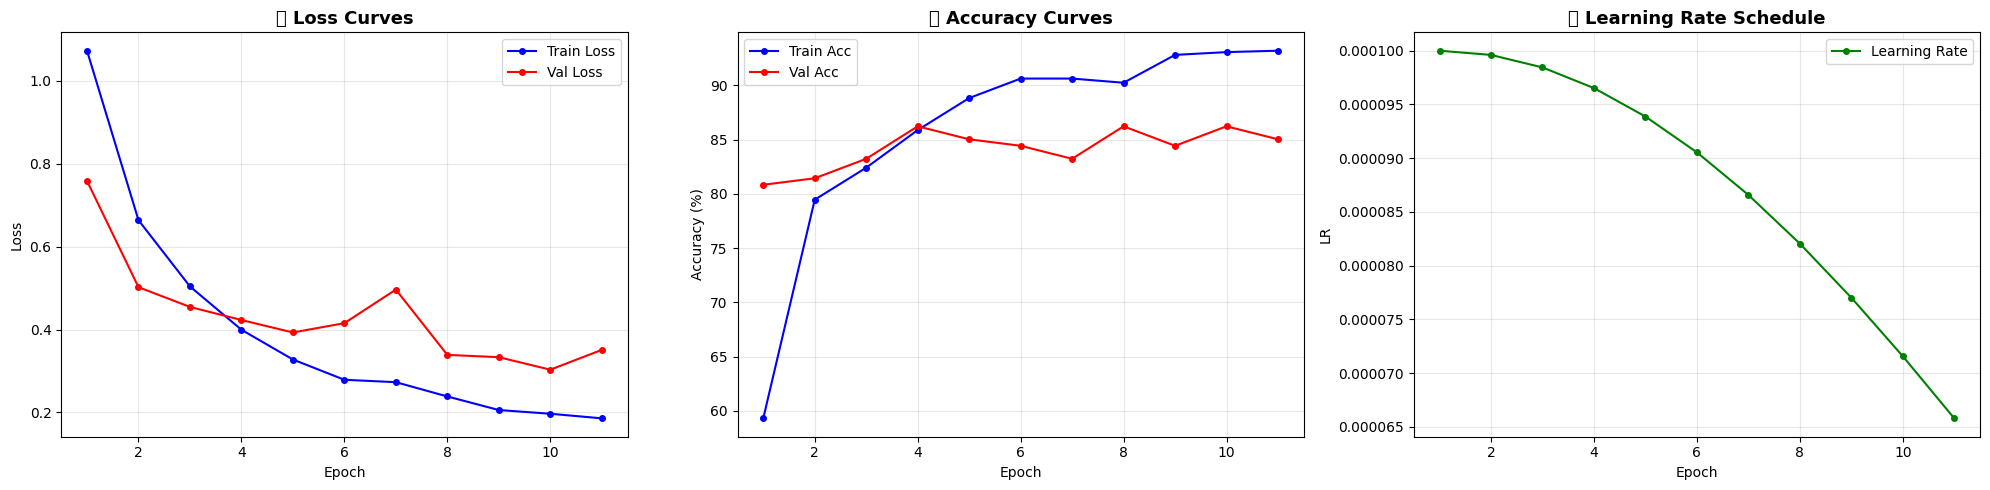

📁 Training history plot saved.


In [13]:
# ── Plot Training History ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_range, history["train_loss"], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history["val_loss"], 'r-o', label='Val Loss', markersize=4)
axes[0].set_title('📉 Loss Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history["train_acc"]], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]], 'r-o', label='Val Acc', markersize=4)
axes[1].set_title('📈 Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# LR
axes[2].plot(epochs_range, history["lr"], 'g-o', label='Learning Rate', markersize=4)
axes[2].set_title('📊 Learning Rate Schedule', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR / "training_history.png", dpi=150, bbox_inches='tight')
plt.show()
print("📁 Training history plot saved.")

## 9. Model Evaluation
Load the best model and evaluate on the held-out test set with a classification report and confusion matrix.

In [14]:
# ── Load Best Model ──────────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

# ── Collect Predictions on Test Set ───────────────────────────────────────────
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Classification Report ────────────────────────────────────────────────────
print("📋 Classification Report (Test Set)")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))

📋 Classification Report (Test Set)
                precision    recall  f1-score   support

   Blepharitis     0.9032    0.8485    0.8750        33
Conjunctivitis     0.9792    0.8704    0.9216        54
        Normal     0.9149    0.9149    0.9149        47
       Uveitis     0.7561    0.9394    0.8378        33

      accuracy                         0.8922       167
     macro avg     0.8883    0.8933    0.8873       167
  weighted avg     0.9020    0.8922    0.8939       167



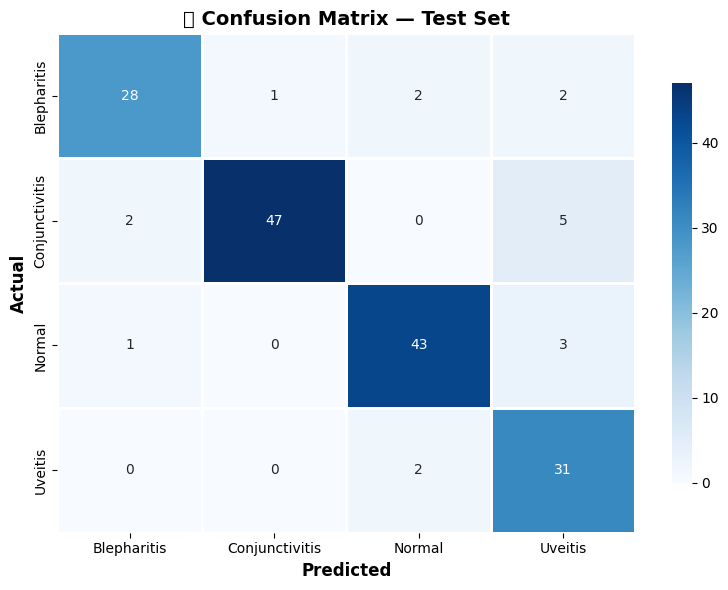


🎯 Test Accuracy: 89.22%


In [15]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("🔍 Confusion Matrix — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

test_acc = np.sum(all_preds == all_labels) / len(all_labels)
print(f"\n🎯 Test Accuracy: {test_acc*100:.2f}%")

## 10. Inference Demo
Demonstrate predictions on random test images with confidence scores.

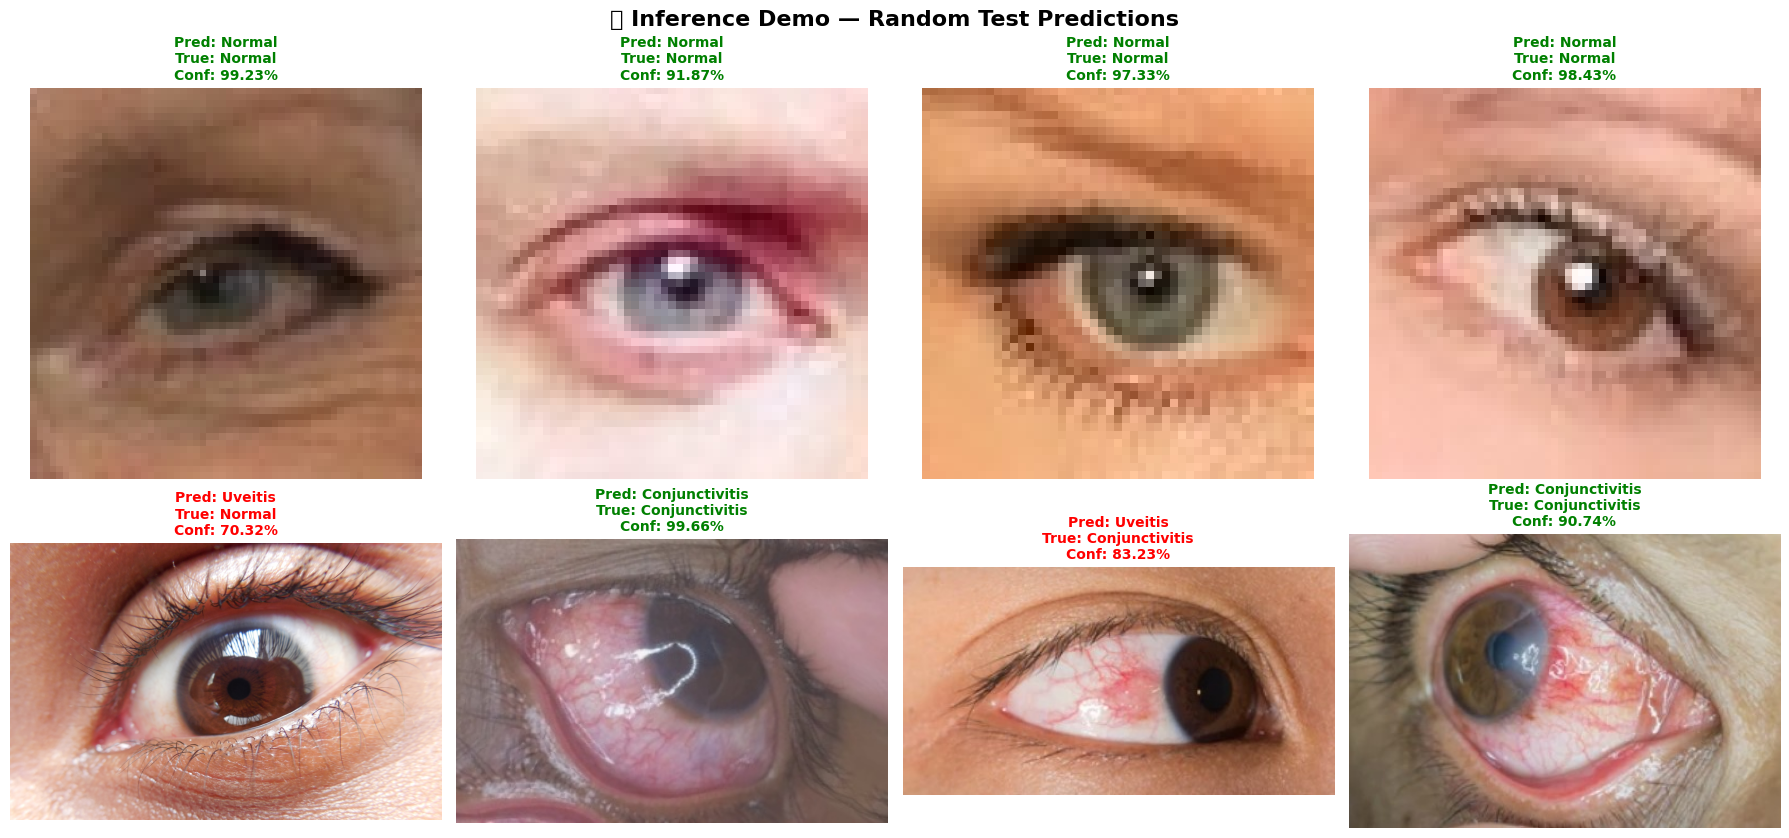

In [16]:
# ── Inference on Random Test Samples ──────────────────────────────────────────
def predict_single(model, image_path, transform, class_names, device):
    """Predict a single image and return class + confidence."""
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        conf, pred = probs.max(1)
    
    return class_names[pred.item()], conf.item(), img

# Select random test images
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("🔬 Inference Demo — Random Test Predictions", fontsize=16, fontweight="bold")

sample_indices = random.sample(range(len(test_subset)), min(8, len(test_subset)))
for idx, ax in zip(sample_indices, axes.flat):
    real_idx = test_idx[idx]
    img_path, true_label = full_dataset.samples[real_idx]
    pred_class, confidence, img = predict_single(model, img_path, val_test_transform, CLASS_NAMES, device)
    true_class = CLASS_NAMES[true_label]
    
    color = "green" if pred_class == true_class else "red"
    ax.imshow(img)
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}\nConf: {confidence:.2%}",
                 fontsize=10, color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 11. Model Export — TFLite Conversion
Convert the trained PyTorch model to **TFLite format** for deployment in a Flutter mobile application.

Pipeline: **PyTorch → ONNX → TensorFlow → TFLite**

In [17]:
# ── Step 1: Export to ONNX ────────────────────────────────────────────────────
import onnx

model.eval()
model_cpu = model.to("cpu")
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

onnx_path = MODEL_DIR / "eye_disease_model.onnx"

torch.onnx.export(
    model_cpu,
    dummy_input,
    str(onnx_path),
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)

# Verify ONNX model
onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)
print(f"✅ ONNX model exported & verified: {onnx_path}")
print(f"   Size: {onnx_path.stat().st_size / 1e6:.2f} MB")

✅ ONNX model exported & verified: c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_model.onnx
   Size: 45.23 MB


In [18]:
# ── Step 2: Convert ONNX → TensorFlow SavedModel ─────────────────────────────
import onnx2tf

tf_output_dir = str(MODEL_DIR / "eye_disease_tf")

onnx2tf.convert(
    input_onnx_file_path=str(onnx_path),
    output_folder_path=tf_output_dir,
    non_verbose=True
)

print(f"✅ TensorFlow SavedModel exported: {tf_output_dir}")


✅ TensorFlow SavedModel exported: c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_tf


In [22]:
# ── Step 3: Convert to TFLite (float16 for mobile) ────────────────────────────
import tensorflow as tf

# Float16 quantized model (good balance of size and accuracy)
converter = tf.lite.TFLiteConverter.from_saved_model(tf_output_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = MODEL_DIR / "eye_disease_mobile.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"✅ TFLite model (float16) saved: {tflite_path}")
print(f"   Size: {tflite_path.stat().st_size / 1e6:.2f} MB")

# Also save full float32 for reference
converter_f32 = tf.lite.TFLiteConverter.from_saved_model(tf_output_dir)
tflite_f32 = converter_f32.convert()
tflite_f32_path = MODEL_DIR / "eye_disease_mobile_f32.tflite"
with open(tflite_f32_path, "wb") as f:
    f.write(tflite_f32)

print(f"✅ TFLite model (float32) saved: {tflite_f32_path}")
print(f"   Size: {tflite_f32_path.stat().st_size / 1e6:.2f} MB")

✅ TFLite model (float16) saved: c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_mobile.tflite
   Size: 22.63 MB
✅ TFLite model (float32) saved: c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_mobile_f32.tflite
   Size: 45.23 MB


In [23]:
# ── Step 4: Save Class Labels for Flutter App ─────────────────────────────────
labels_path = MODEL_DIR / "labels.txt"
with open(labels_path, "w") as f:
    for name in CLASS_NAMES:
        f.write(f"{name}\n")

print(f"✅ Labels file saved: {labels_path}")
print(f"   Classes: {CLASS_NAMES}")

# ── Summary ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📦 Export Summary")
print("=" * 60)
print(f"   PyTorch model  : {best_model_path}")
print(f"   ONNX model     : {onnx_path}")
print(f"   TFLite (fp16)  : {tflite_path}")
print(f"   TFLite (fp32)  : {tflite_f32_path}")
print(f"   Labels         : {labels_path}")
print(f"\n✅ All exports complete! Ready for Flutter integration.")

✅ Labels file saved: c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\labels.txt
   Classes: ['Blepharitis', 'Conjunctivitis', 'Normal', 'Uveitis']

📦 Export Summary
   PyTorch model  : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_resnet18_best.pth
   ONNX model     : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_model.onnx
   TFLite (fp16)  : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_mobile.tflite
   TFLite (fp32)  : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\eye_disease_mobile_f32.tflite
   Labels         : c:\Users\Ahmer Adnan\OneDrive\Desktop\Eyes\models\labels.txt

✅ All exports complete! Ready for Flutter integration.


In [24]:
# ── Verify TFLite Model ──────────────────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("🔍 TFLite Model Verification")
print(f"   Input shape  : {input_details[0]['shape']}")
print(f"   Input dtype  : {input_details[0]['dtype']}")
print(f"   Output shape : {output_details[0]['shape']}")
print(f"   Output dtype : {output_details[0]['dtype']}")
print(f"\n✅ TFLite model verified successfully!")

🔍 TFLite Model Verification
   Input shape  : [  1 224 224   3]
   Input dtype  : <class 'numpy.float32'>
   Output shape : [1 4]
   Output dtype : <class 'numpy.float32'>

✅ TFLite model verified successfully!
